<a href="https://colab.research.google.com/github/pitagorasman/Tareas-Computo-Emergente/blob/main/Algoritmos%20Geneticos/Tarea_Algoritmos_Geneticos_03.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **El Problema del Viajante de Comercio (TSP)**

El TSP es uno de los problemas más famosos dentro de la categoría de optimización combinatoria y es catalogado como NP-completo. El objetivo es simple de enunciar pero extremadamente complejo de resolver computacionalmente: dada una lista de ciudades y las distancias entre ellas, se debe buscar el recorrido de longitud mínima que visite cada ciudad exactamente una vez y vuelva al punto de partida.  

¿Por qué es un reto computacional?

El número de posibles recorridos (el espacio de búsqueda) crece factorialmente. Para $N$ ciudades, hay $(N-1)! / 2$ rutas posibles. Si usamos 15 ciudades, estamos hablando de más de 43 mil millones de rutas. Debido a esta explosión combinatoria, calcular todas las secuencias para tomar la menor no es factible en tiempos razonables. Es aquí donde métodos de poda inteligente del espacio de soluciones, como los Algoritmos Genéticos (AG), brillan por su utilidad.  

Elementos del Algoritmo Evolutivo para el TSP:

Representación (Codificación): La forma más directa es usar una permutación de enteros. Si tenemos $N$ ciudades etiquetadas del 0 al $N-1$, un cromosoma válido sería [2, 0, 4, 1, 3]. No podemos usar binarios simples porque debemos garantizar la restricción fundamental: no pasar dos veces por la misma ciudad.

Función de Costo (Fitness): Viene dada por la suma de todas las distancias euclidianas recorridas entre las ciudades en el orden del cromosoma. El objetivo es minimizar esta función $F$.  

Operadores Especializados:

Cruce de Orden (Order Crossover - OX): Hereda una subcadena de ciudades de un padre y rellena el resto con el orden relativo del otro padre, evitando duplicados.

Mutación por Intercambio (Swap Mutation): Selecciona dos ciudades al azar en el recorrido y las intercambia de posición, aportando diversidad.

Configuración Espacial: Siguiendo la recomendación del problema, ensayaremos con un conjunto de ciudades (por ejemplo, $N=15$, dentro del rango de 8 a 20 recomendado) ubicadas en torno a un círculo. Esto facilita la evaluación visual, ya que la ruta óptima teórica será el perímetro exacto del círculo, sin líneas que se crucen en el centro.

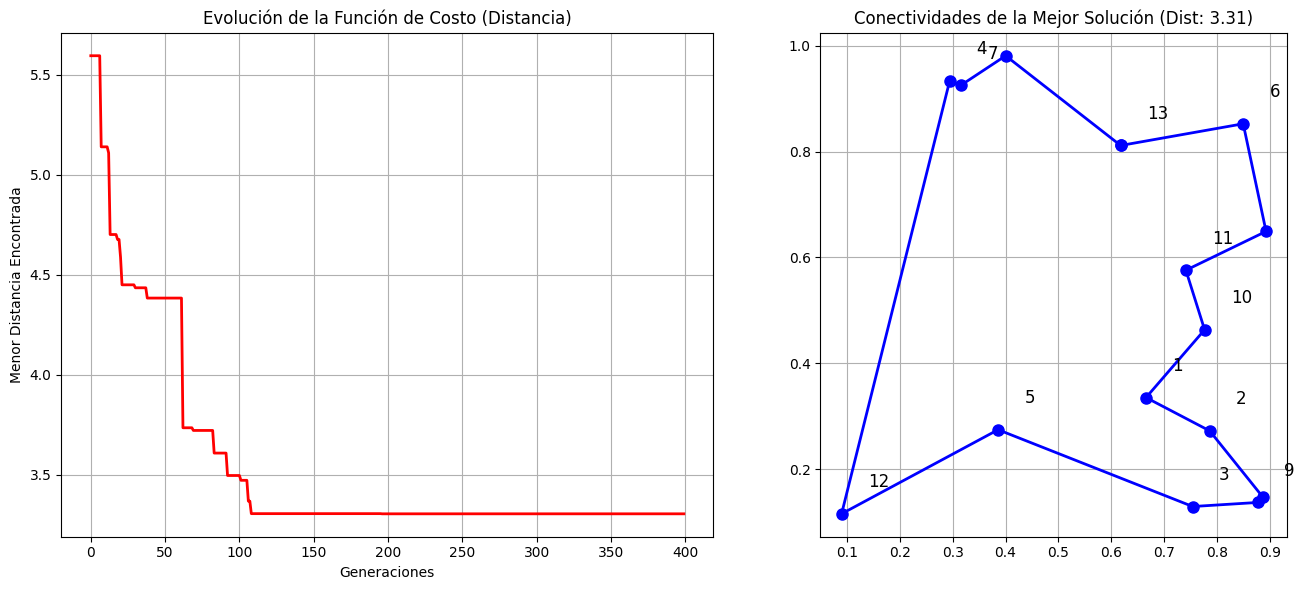

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import random

#  PARÁMETROS DEL EXPERIMENTO
N_CITIES = 15      # Recomendado entre 8 a 20 ciudades
POP_SIZE = 100     # Tamaño de la población
GENS = 400         # Número de generaciones
P_C = 0.8          # Probabilidad de cruce
P_M = 0.1          # Probabilidad de mutación (Se usa más alta en TSP para evitar mínimos locales)

#  1. GENERACIÓN DEL MAPA DE CIUDADES
angles = np.linspace(0, 2 * np.pi, N_CITIES, endpoint=False)
# Desordenamos los ángulos para que el estado inicial no sea el óptimo
np.random.shuffle(angles)
#1 Inicio circular, ciudades equidistantes, 2 ciudades aleatorias
#ciudades = np.column_stack((np.cos(angles), np.sin(angles)))
ciudades = np.random.rand(N_CITIES, 2)

def calcular_distancia_total(ruta):
    """Calcula la distancia total (Costo) de un recorrido."""
    distancia = 0
    for i in range(len(ruta)):
        c1 = ciudades[ruta[i]]
        c2 = ciudades[ruta[(i + 1) % len(ruta)]] # Conecta la última ciudad con la primera
        distancia += np.linalg.norm(c1 - c2)
    return distancia

# 2. OPERADORES GENÉTICOS PARA PERMUTACIONES
def init_population(pop_size, n_cities):
    """Crea la población inicial con permutaciones aleatorias."""
    pop = []
    for _ in range(pop_size):
        ind = list(range(n_cities))
        random.shuffle(ind)
        pop.append(ind)
    return pop

def roulette_selection(population, fitnesses):
    """Selección por ruleta proporcional al fitness (Inverso de la distancia)."""
    total_fit = sum(fitnesses)
    pick = random.uniform(0, total_fit)
    current = 0
    for ind, fit in zip(population, fitnesses):
        current += fit
        if current >= pick:
            return ind

def order_crossover(p1, p2, pc):
    """Cruce de Orden (OX) para evitar ciudades duplicadas."""
    if random.random() < pc:
        size = len(p1)
        start, end = sorted(random.sample(range(size), 2))

        # Crear hijo 1
        c1 = [-1] * size
        c1[start:end] = p1[start:end]
        p2_filtered = [x for x in p2 if x not in c1]
        idx = 0
        for i in range(size):
            if c1[i] == -1:
                c1[i] = p2_filtered[idx]
                idx += 1

        # Crear hijo 2
        c2 = [-1] * size
        c2[start:end] = p2[start:end]
        p1_filtered = [x for x in p1 if x not in c2]
        idx = 0
        for i in range(size):
            if c2[i] == -1:
                c2[i] = p1_filtered[idx]
                idx += 1

        return c1, c2
    return p1[:], p2[:]

def swap_mutation(ruta, pm):
    """Mutación por intercambio de dos ciudades aleatorias."""
    if random.random() < pm:
        idx1, idx2 = random.sample(range(len(ruta)), 2)
        ruta[idx1], ruta[idx2] = ruta[idx2], ruta[idx1]
    return ruta

# 3. BUCLE PRINCIPAL DEL ALGORITMO EVOLUTIVO
population = init_population(POP_SIZE, N_CITIES)
historial_mejores_distancias = []
mejor_ruta_global = None
mejor_dist_global = float('inf')

for gen in range(GENS):
    # Evaluar costos y fitness (se busca minimizar distancia, por lo que fitness = 1/distancia)
    distancias = [calcular_distancia_total(ind) for ind in population]
    fitnesses = [1.0 / dist for dist in distancias]

    # Guardar el mejor de la generación
    min_dist_gen = min(distancias)
    historial_mejores_distancias.append(min_dist_gen)

    if min_dist_gen < mejor_dist_global:
        mejor_dist_global = min_dist_gen
        mejor_ruta_global = population[distancias.index(min_dist_gen)].copy()

    # Nueva población
    new_population = []
    # Elitismo: Conservamos al mejor individuo intacto para no perder la mejor solución
    new_population.append(mejor_ruta_global)

    while len(new_population) < POP_SIZE:
        p1 = roulette_selection(population, fitnesses)
        p2 = roulette_selection(population, fitnesses)

        c1, c2 = order_crossover(p1, p2, P_C)

        c1 = swap_mutation(c1, P_M)
        c2 = swap_mutation(c2, P_M)

        new_population.extend([c1, c2])

    population = new_population[:POP_SIZE]

# 4. VISUALIZACIÓN GRÁFICA
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Gráfica 1: Historial de la optimización
ax1.plot(historial_mejores_distancias, color='red', linewidth=2)
ax1.set_title('Evolución de la Función de Costo (Distancia)')
ax1.set_xlabel('Generaciones')
ax1.set_ylabel('Menor Distancia Encontrada')
ax1.grid(True)

# Gráfica 2: Mejor Ruta Encontrada
ruta_coords = ciudades[mejor_ruta_global + [mejor_ruta_global[0]]] # Cerrar el ciclo
ax2.plot(ruta_coords[:, 0], ruta_coords[:, 1], marker='o', markersize=8, color='blue', linestyle='-', linewidth=2)
# Anotar el índice de las ciudades
for i, coord in enumerate(ciudades):
    ax2.annotate(str(i), (coord[0]+0.05, coord[1]+0.05), fontsize=12)

ax2.set_title(f'Conectividades de la Mejor Solución (Dist: {mejor_dist_global:.2f})')
ax2.set_aspect('equal')
ax2.grid(True)

plt.tight_layout()
plt.show()

# **Explicación Paso a Paso**

El Mapa Inicial: Creamos N_CITIES = 15 ciudades utilizando coordenadas polares (Seno y Coseno) para formar un círculo. El truco está en que desordenamos sus posiciones intencionalmente (np.random.shuffle). Si no lo hiciéramos, el orden natural (0, 1, 2... 14) ya sería la solución perfecta.  

Evaluación de la Restricción: La codificación usa una lista de enteros (ej. [3, 8, 1...]). Esto asegura matemáticamente que no se puede pasar dos veces por la misma ciudad, cumpliendo con la regla de oro del problema.  

El Operador de Cruce (OX): Es la parte más compleja. Selecciona un segmento aleatorio de ciudades del Padre 1 y se lo pasa al Hijo 1. Luego, recorre el Padre 2 y va llenando los huecos del Hijo 1 solo con las ciudades que aún faltan. Así, mezclamos características de ambas rutas sin violar la restricción del TSP.

Elitismo: En el bloque principal del algoritmo verás la línea new_population.append(mejor_ruta_global). Esto se llama Elitismo, e impide que mutaciones destructivas borren la mejor solución que hemos conseguido, garantizando que la curva de convergencia siempre baje o se mantenga plana, nunca suba.

Al ver las gráficas resultantes, la gráfica de la izquierda muestra cómo se desploma la distancia a medida que el algoritmo "aprende". La gráfica de la derecha mostrará las ciudades unidas. Al estar en círculo, se puede ver que el algoritmo encontró el óptimo global (o está muy cerca) cuando las líneas de conexión conformen el perímetro del círculo, sin que ninguna línea cruce por el centro geométrico de la figura.  

Ejecutando simulaciones 3D para el TSP... (Puede tomar un par de minutos)


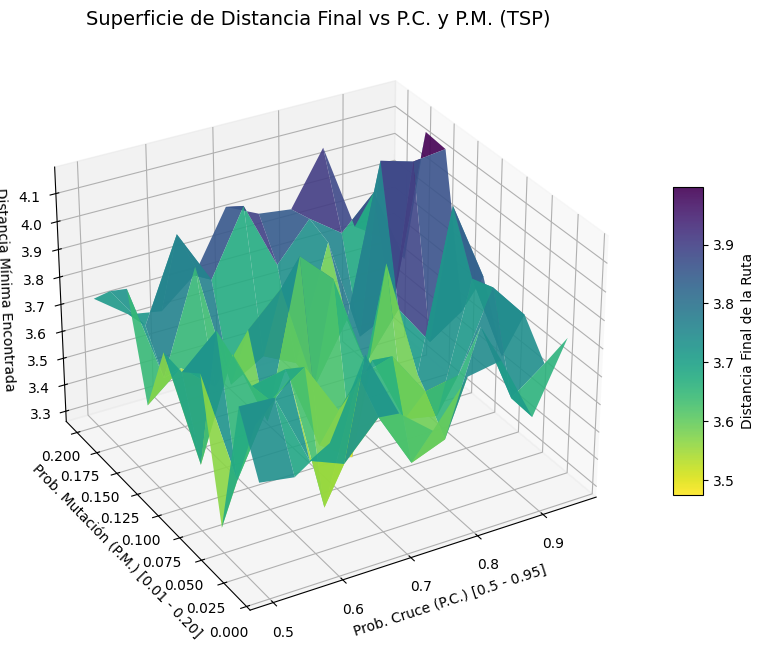

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import random

# PARÁMETROS BASE
N_CITIES = 15
POP_SIZE = 50      # Reducido un poco para acelerar el barrido 3D
GENS = 100         # Generaciones por simulación
RUNS_PER_POINT = 3 # Simulaciones por cada nodo de la malla

# 1. Mapa de Ciudades (Fijo para que todas las simulaciones compitan en igualdad de condiciones)
np.random.seed(42) # Semilla para reproducibilidad
ciudades = np.random.rand(N_CITIES, 2)

def calcular_distancia_total(ruta):
    distancia = 0
    for i in range(len(ruta)):
        c1 = ciudades[ruta[i]]
        c2 = ciudades[ruta[(i + 1) % len(ruta)]]
        distancia += np.linalg.norm(c1 - c2)
    return distancia

# OPERADORES GENÉTICOS (Compactos)
def roulette_selection(population, fitnesses):
    pick = random.uniform(0, sum(fitnesses))
    current = 0
    for ind, fit in zip(population, fitnesses):
        current += fit
        if current >= pick: return ind
    return population[-1]

def order_crossover(p1, p2, pc):
    if random.random() < pc:
        size = len(p1)
        start, end = sorted(random.sample(range(size), 2))
        c1, c2 = [-1]*size, [-1]*size
        c1[start:end], c2[start:end] = p1[start:end], p2[start:end]

        p2_f, p1_f = [x for x in p2 if x not in c1], [x for x in p1 if x not in c2]
        idx1, idx2 = 0, 0
        for i in range(size):
            if c1[i] == -1: c1[i] = p2_f[idx1]; idx1 += 1
            if c2[i] == -1: c2[i] = p1_f[idx2]; idx2 += 1
        return c1, c2
    return p1[:], p2[:]

def swap_mutation(ruta, pm):
    if random.random() < pm:
        idx1, idx2 = random.sample(range(len(ruta)), 2)
        ruta[idx1], ruta[idx2] = ruta[idx2], ruta[idx1]
    return ruta

# FUNCIÓN DE SIMULACIÓN ÚNICA
def run_tsp_ga(pc, pm):
    """Ejecuta una corrida del A.G. para el TSP y retorna la mejor distancia."""
    population = [random.sample(range(N_CITIES), N_CITIES) for _ in range(POP_SIZE)]
    best_dist = float('inf')

    for _ in range(GENS):
        distancias = [calcular_distancia_total(ind) for ind in population]
        fitnesses = [1.0 / d for d in distancias]

        min_d = min(distancias)
        if min_d < best_dist:
            best_dist = min_d
            best_ruta = population[distancias.index(min_d)].copy()

        new_pop = [best_ruta] # Elitismo
        while len(new_pop) < POP_SIZE:
            p1 = roulette_selection(population, fitnesses)
            p2 = roulette_selection(population, fitnesses)
            c1, c2 = order_crossover(p1, p2, pc)
            new_pop.extend([swap_mutation(c1, pm), swap_mutation(c2, pm)])

        population = new_pop[:POP_SIZE]

    return best_dist

# BARRIDO PARAMÉTRICO 3D
# Malla de valores: P.C. alto para heredar sub-rutas, P.M. ampliado para desatar nudos
p_c_vals = np.linspace(0.5, 0.95, 10)
p_m_vals = np.linspace(0.01, 0.20, 10)

PC, PM = np.meshgrid(p_c_vals, p_m_vals)
Z_distance = np.zeros_like(PC)

for i in range(PC.shape[0]):
    for j in range(PC.shape[1]):
        avg_best = 0
        for _ in range(RUNS_PER_POINT):
            avg_best += run_tsp_ga(PC[i,j], PM[i,j])
        Z_distance[i,j] = avg_best / RUNS_PER_POINT

# GRÁFICA 3D
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')
# Usamos un mapa de colores donde los valores más bajos (mejores) sean más fríos
surf = ax.plot_surface(PC, PM, Z_distance, cmap='viridis_r', edgecolor='none', alpha=0.9)

ax.set_title('Superficie de Distancia Final vs P.C. y P.M. (TSP)', fontsize=14)
ax.set_xlabel('Prob. Cruce (P.C.) [0.5 - 0.95]')
ax.set_ylabel('Prob. Mutación (P.M.) [0.01 - 0.20]')
ax.set_zlabel('Distancia Mínima Encontrada')
fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10, label='Distancia Final de la Ruta')

ax.view_init(elev=30, azim=-120)
plt.show()